In [8]:
import pandas as pd

In [9]:
ARQUIVO_CSV = "resultados_total.csv"

In [10]:
df = pd.read_csv(ARQUIVO_CSV, sep=";")

# Remove espaços extras dos nomes das colunas
df.columns = df.columns.str.strip()

print(df.head())

        seed  temp_inicial  temp_final  alpha  iteracoes_por_temp  operador  \
0  159768904         500.0       0.001    0.9                   1         0   
1  230236244         500.0       0.001    0.9                   1         0   
2  291940609         500.0       0.001    0.9                   1         0   
3  356008268         500.0       0.001    0.9                   1         0   
4  435864008         500.0       0.001    0.9                   1         0   

   final_losses  visited  total_iteracoes  tempo_execucao  
0    215.053509      437              125        0.049509  
1    214.545552      465              125        0.047504  
2    214.448520      404              125        0.048980  
3    213.941448      419              125        0.056221  
4    214.473918      440              125        0.049237  


In [12]:
# =========================================
# CÉLULA 5 - CONFIGURAÇÕES E MÉTRICAS
# =========================================

config_cols = [
    "temp_inicial",
    "temp_final",
    "alpha",
    "iteracoes_por_temp",
    "operador"
]

metricas = [
    "final_losses",
    "visited",
    "total_iteracoes",
    "tempo_execucao"
]

In [13]:
# =========================================
# CÉLULA 6 - MÉDIA E DESVIO PADRÃO
# =========================================

resultado = (
    df.groupby(config_cols)[metricas]
    .agg(["mean", "std"])
    .reset_index()
)

# Ajusta nomes das colunas
resultado.columns = [
    "_".join(col).strip("_")
    for col in resultado.columns.values
]

print(resultado.head())

   temp_inicial  temp_final  alpha  iteracoes_por_temp  operador  \
0         500.0       0.001    0.9                   1         0   
1         500.0       0.001    0.9                   1         1   
2         500.0       0.001    0.9                   1         2   
3         500.0       0.001    0.9                  10         0   
4         500.0       0.001    0.9                  10         1   

   final_losses_mean  final_losses_std  visited_mean  visited_std  \
0         214.498773          1.007524        435.00    20.652514   
1         213.848139          0.324757        377.00    29.616852   
2         214.162122          0.411758        421.20    28.614682   
3         213.490687          0.017881       1948.15    60.894451   
4         213.480636          0.002357       1733.90    52.308699   

   total_iteracoes_mean  total_iteracoes_std  tempo_execucao_mean  \
0                 125.0                  0.0             0.049489   
1                 125.0               

In [15]:
# =========================================
# CÉLULA 7 - RANKING COM CRITÉRIOS
# =========================================

ranking = (
    resultado.sort_values(
        by=[
            "final_losses_mean",     # 1. menor perda média
            "final_losses_std",      # 2. menor desvio padrão
            "total_iteracoes_mean",  # 3. menor quantidade de interações
            "visited_mean"           # 4. menor média de visitados
        ],
        ascending=[True, True, True, True]
    )
    .reset_index(drop=True)
)

ranking["ranking"] = ranking.index + 1

print(ranking.head())

   temp_inicial  temp_final  alpha  iteracoes_por_temp  operador  \
0        2500.0       0.001  0.990                   1         1   
1         500.0       0.001  0.950                  10         1   
2        1000.0       0.001  0.950                  10         1   
3        2500.0       0.001  0.950                  10         1   
4         500.0       0.001  0.975                  10         1   

   final_losses_mean  final_losses_std  visited_mean  visited_std  \
0         213.479926               0.0       1998.30    61.896433   
1         213.479926               0.0       2528.45    66.166835   
2         213.479926               0.0       2655.50    69.637029   
3         213.479926               0.0       2822.30    54.150959   
4         213.479926               0.0       3354.75    36.913662   

   total_iteracoes_mean  total_iteracoes_std  tempo_execucao_mean  \
0                1466.0                  0.0             0.205910   
1                2560.0               

In [16]:
# =========================================
# CÉLULA 8 - TOP 20 CONFIGURAÇÕES
# =========================================

top20 = ranking[
    [
        "ranking",
        "temp_inicial",
        "temp_final",
        "alpha",
        "iteracoes_por_temp",
        "operador",
        "final_losses_mean",
        "final_losses_std",
        "visited_mean",
        "visited_std",
        "total_iteracoes_mean",
        "tempo_execucao_mean"
    ]
].head(20)

print("\n===== TOP 20 CONFIGURAÇÕES =====\n")

display(top20)


===== TOP 20 CONFIGURAÇÕES =====



,ranking,temp_inicial,temp_final,alpha,iteracoes_por_temp,operador,final_losses_mean,final_losses_std,visited_mean,visited_std,total_iteracoes_mean,tempo_execucao_mean
0,1,2500.0,0.001,0.990,1,1,213.479926,0.0,1998.30,61.896433,1466.0,0.205910
1,2,500.0,0.001,0.950,10,1,213.479926,0.0,2528.45,66.166835,2560.0,0.257808
2,3,1000.0,0.001,0.950,10,1,213.479926,0.0,2655.50,69.637029,2700.0,0.269142
3,4,2500.0,0.001,0.950,10,1,213.479926,0.0,2822.30,54.150959,2880.0,0.295065
4,5,500.0,0.001,0.975,10,1,213.479926,0.0,3354.75,36.913662,5190.0,0.754952
5,6,1000.0,0.001,0.975,10,1,213.479926,0.0,3468.40,46.641296,5460.0,0.665251
6,7,1000.0,0.001,0.975,10,2,213.479926,0.0,3575.20,37.724207,5460.0,0.689108
7,8,2500.0,0.001,0.975,10,1,213.479926,0.0,3604.90,33.197812,5820.0,0.748250
8,9,2500.0,0.001,0.975,10,2,213.479926,0.0,3692.25,29.486616,5820.0,0.763118
9,10,5000.0,0.001,0.975,10,1,213.479926,0.0,3684.05,39.940054,6100.0,0.695986


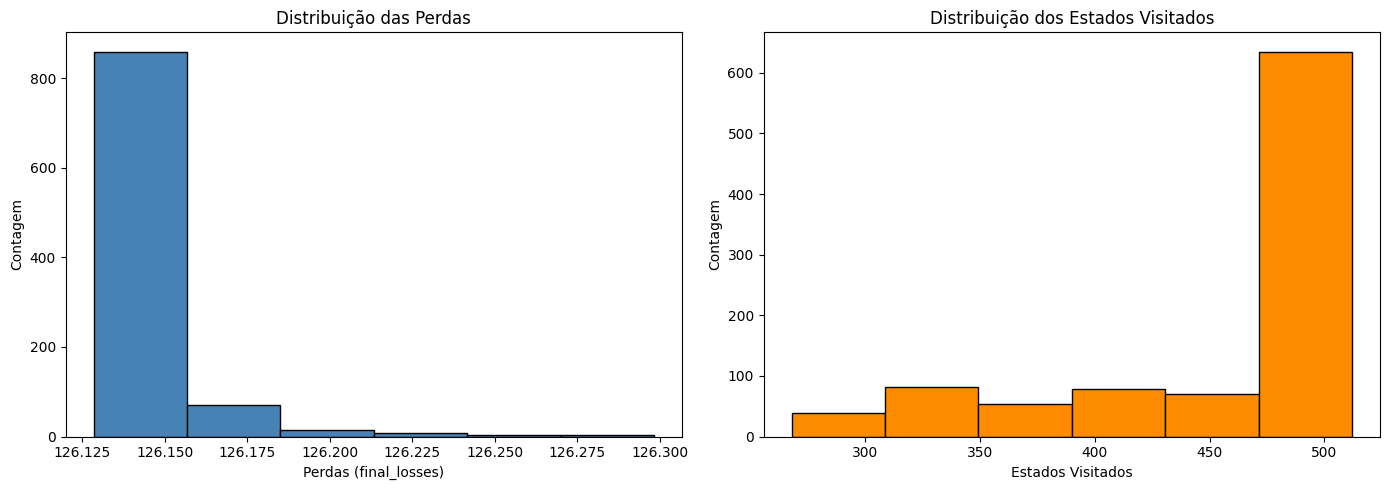

Salvo em histogramas.png


In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('resultados_14_barras.csv', sep=';', skipinitialspace=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Histograma 1 - Perdas
ax1.hist(df['final_losses'], bins=6, color='steelblue', edgecolor='black')
ax1.set_xlabel('Perdas (final_losses)')
ax1.set_ylabel('Contagem')
ax1.set_title('Distribuição das Perdas')

# Histograma 2 - Estados visitados
ax2.hist(df['visited'], bins=6, color='darkorange', edgecolor='black')
ax2.set_xlabel('Estados Visitados')
ax2.set_ylabel('Contagem')
ax2.set_title('Distribuição dos Estados Visitados')

plt.tight_layout()
plt.savefig('histogramas.png', dpi=150)
plt.show()

print("Salvo em histogramas.png")